# Лабораторная работа 2. Ассоциативные правила

## Цель работы:
Исследование методов анализа ассоциативных правил

## Датасет
**Источник:** [Groceries Market Basket Dataset](https://www.kaggle.com/datasets/irfanasrullah/groceries)

## Описание
Набор данных о корзине продуктового рынка. Он содержит 9835 транзакций покупателей, покупающих продукты. Данные содержат 169 уникальных товаров.

**Основные характеристики:**
- Объем данных: 9835 транзакций.
- 169 уникальных товаров.


## Описание переменных датасета

| Переменная | Описание |
|------------|-----------|
| **Items** | Количество продуктов в корзине |
| **Item1-32** | Название продукта (первого, второго и т.д.) |

In [2]:
#python -m pip install matplotlib pandas scikit-learn seaborn jupyter numpy ipykernel
 

In [11]:
# # Импорт библиотек
import pandas as pd
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
from statsmodels.stats.outliers_influence import variance_inflation_factor
from scipy.stats import skew, kurtosis, kstest
from mlxtend.preprocessing import TransactionEncoder
from mlxtend.frequent_patterns import apriori, association_rules, fpgrowth
import networkx as nx


## 1. Загрузка данных из датасета

In [3]:
# Чтение данных из файла в датафрейм. Настройки
path = 'groceries - groceries.csv'
# drop_columns = ['dteday', 'instant', 'Transaction date', 'Country or region', 'Id']
# target = 'MEDV'

pd.set_option('display.float_format', '{:.2f}'.format)
all_data = pd.read_csv(path)
print(all_data)


      Item(s)               Item 1               Item 2            Item 3  \
0           4         citrus fruit  semi-finished bread         margarine   
1           3       tropical fruit               yogurt            coffee   
2           1           whole milk                  NaN               NaN   
3           4            pip fruit               yogurt      cream cheese   
4           4     other vegetables           whole milk    condensed milk   
...       ...                  ...                  ...               ...   
9830       17              sausage              chicken              beef   
9831        1    cooking chocolate                  NaN               NaN   
9832       10              chicken         citrus fruit  other vegetables   
9833        4  semi-finished bread        bottled water              soda   
9834        5              chicken       tropical fruit  other vegetables   

                        Item 4         Item 5          Item 6  \
0         

Все данные загружены.

## 2. Описание данных из датасета

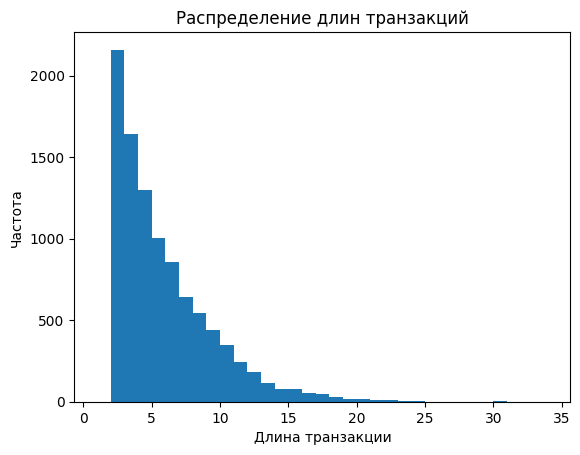

In [4]:
#Анализ транзакций
transaction_lengths = all_data.notnull().sum(axis=1)
plt.hist(transaction_lengths, bins=range(1, max(transaction_lengths) + 2))
plt.xlabel('Длина транзакции')
plt.ylabel('Частота')
plt.title('Распределение длин транзакций')
plt.show()


Распределение длин транзакций визуально похоже на экспоненциальное

In [9]:
#Очистка данных
np_data = all_data.to_numpy()
np_data = [[elem for elem in row[1:] if isinstance(elem,str)] for row in np_data]

#Список уникальных товаров
unique_items = set()
for row in np_data:
    for elem in row:
        unique_items.add(elem)
print(*unique_items, sep=', ')
print('Количество уникальных товаров:', len(unique_items))

meat, artif. sweetener, house keeping products, salt, salty snack, cleaner, pudding powder, misc. beverages, condensed milk, white wine, organic sausage, pip fruit, female sanitary products, cake bar, pork, chocolate marshmallow, light bulbs, cereals, flour, red/blush wine, jam, nuts/prunes, male cosmetics, finished products, vinegar, nut snack, baby food, specialty chocolate, honey, sausage, chocolate, kitchen utensil, onions, soft cheese, instant coffee, shopping bags, softener, candy, popcorn, beef, cream cheese, dishes, sugar, frozen potato products, frankfurter, roll products, soda, photo/film, specialty cheese, hair spray, syrup, bottled beer, root vegetables, kitchen towels, whole milk, berries, make up remover, salad dressing, hamburger meat, packaged fruit/vegetables, frozen chicken, oil, dog food, grapes, tropical fruit, canned vegetables, curd cheese, bathroom cleaner, fruit/vegetable juice, spread cheese, tidbits, butter, semi-finished bread, rolls/buns, cat food, ketchup, 

In [13]:
# Создание и обучение энкодера
te = TransactionEncoder()
te_ary = te.fit(np_data).transform(np_data)
data = pd.DataFrame(te_ary, columns=te.columns_)

## 3. Алгоритм Apriori

In [60]:
# Алгоритм Apriori
df1 = apriori(data, min_support=0.03, use_colnames = True)
print(df1)
rules = association_rules(df1, metric = "confidence", min_threshold = 0.3)
print(rules)


    support                          itemsets
0      0.03                        (UHT-milk)
1      0.05                            (beef)
2      0.03                         (berries)
3      0.08                    (bottled beer)
4      0.11                   (bottled water)
..      ...                               ...
58     0.05     (root vegetables, whole milk)
59     0.04                (soda, whole milk)
60     0.04      (tropical fruit, whole milk)
61     0.03  (whole milk, whipped/sour cream)
62     0.06              (yogurt, whole milk)

[63 rows x 2 columns]
             antecedents         consequents  antecedent support  \
0        (bottled water)        (whole milk)                0.11   
1         (citrus fruit)        (whole milk)                0.08   
2      (root vegetables)  (other vegetables)                0.11   
3       (tropical fruit)  (other vegetables)                0.10   
4     (other vegetables)        (whole milk)                0.19   
5               (

    support          itemsets
42     0.26        whole milk
26     0.19  other vegetables
30     0.18        rolls/buns
35     0.17              soda
43     0.14            yogurt
4      0.11     bottled water
31     0.11   root vegetables
38     0.10    tropical fruit
34     0.10     shopping bags
33     0.09           sausage


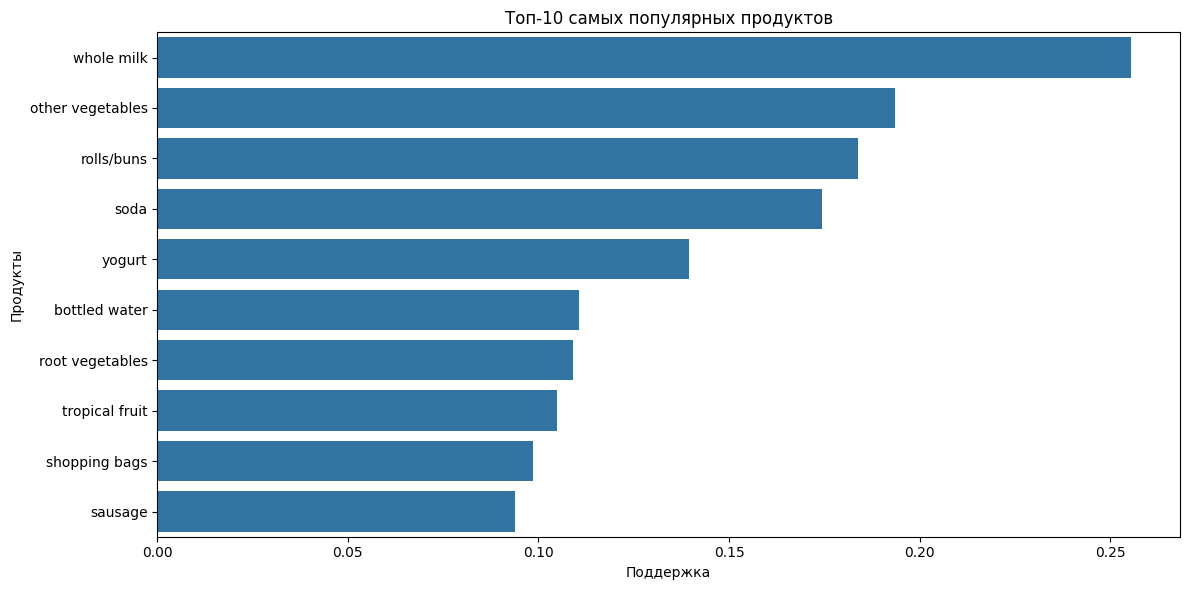

In [61]:
#Поддержка
df1['itemsets'] = df1['itemsets'].apply(lambda x: ', '.join(list(x)))
top_products = df1.sort_values(by='support', ascending=False).head(10)
print(top_products)
plt.figure(figsize=(12, 6))
sns.barplot(x='support', y='itemsets', data=top_products)
plt.title('Топ-10 самых популярных продуктов')
plt.xlabel('Поддержка')
plt.ylabel('Продукты')
plt.tight_layout()
plt.show()


Самое высокое значение support среди товаров имеет whole milk

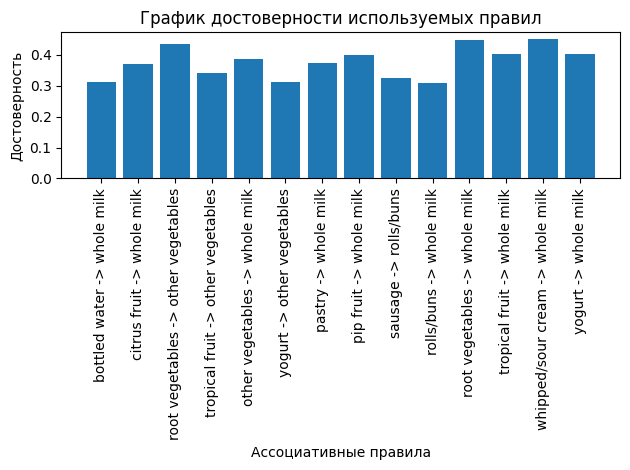

In [62]:
rules['antecedents'] = rules['antecedents'].apply(lambda x: ', '.join(list(x)))
rules['consequents'] = rules['consequents'].apply(lambda x: ', '.join(list(x)))
#График достоверности используемых правил
products_1 = rules["antecedents"].tolist()
products_2 = rules["consequents"].tolist()
confidence = rules["confidence"].tolist()
rules_labels = [f"{product1} -> {product2}" for product1, product2 in zip(products_1, products_2)]
plt.bar(rules_labels, confidence)
plt.xlabel("Ассоциативные правила")
plt.ylabel("Достоверность")
plt.title("График достоверности используемых правил")
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()


<Figure size 1200x800 with 0 Axes>

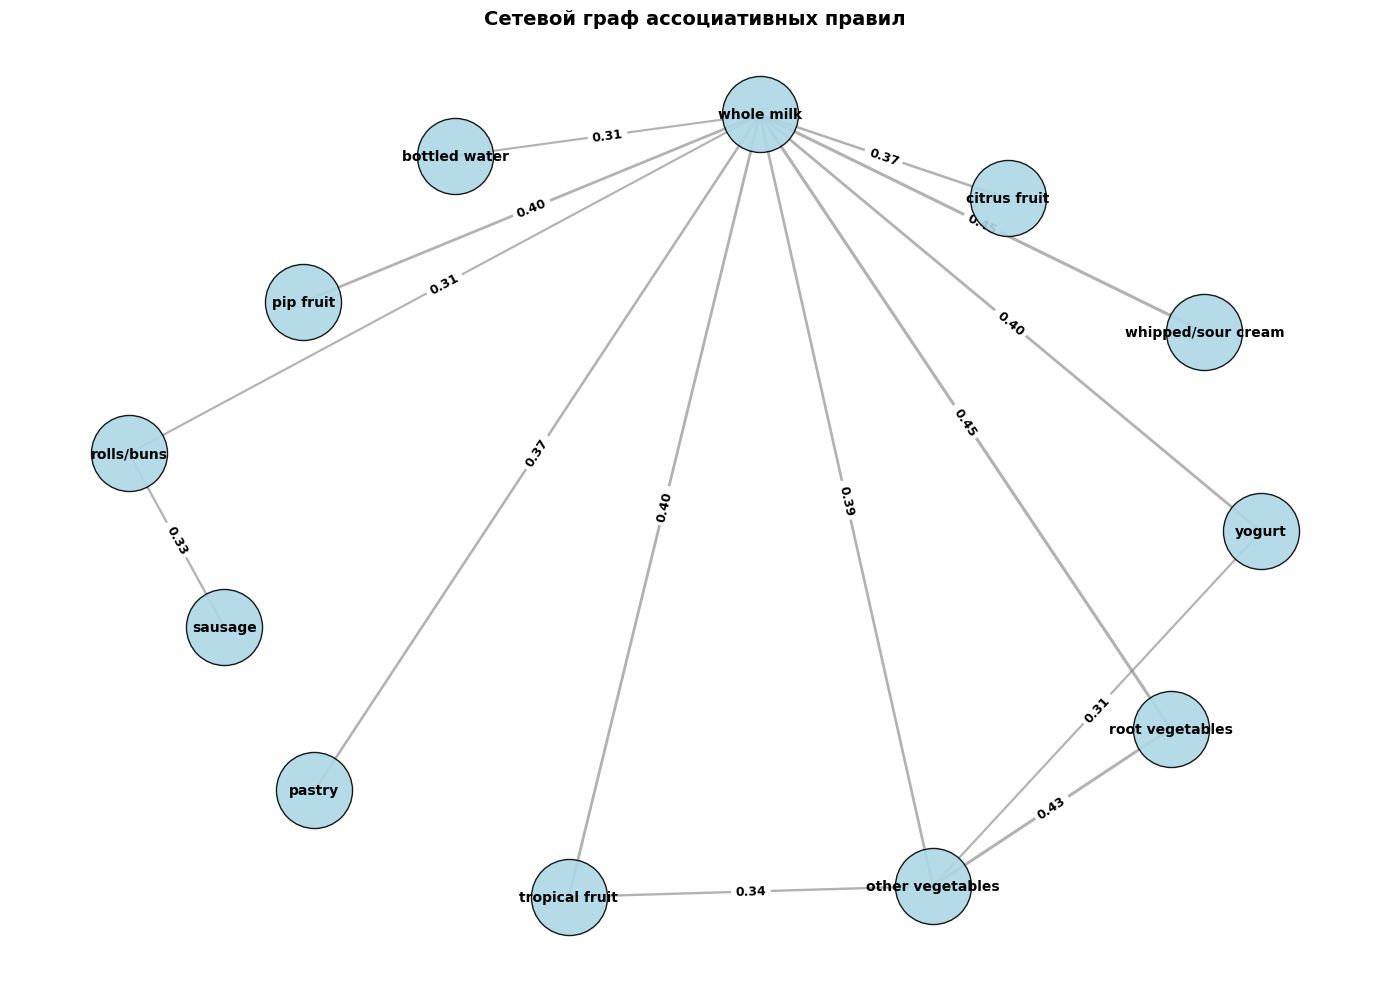

In [63]:
# Визуализация ассоциативных правил в виде графа
plt.figure(figsize=(12, 8))

G = nx.Graph()

for index, row in rules.iterrows():
    G.add_edge(row['antecedents'], row['consequents'], weight=row['confidence'])


pos = nx.spring_layout(G, k=3, iterations=50)

plt.figure(figsize=(14, 10))
nx.draw_networkx_nodes(G, pos, 
                      node_size=3000, 
                      node_color='lightblue',
                      alpha=0.9,
                      edgecolors='black')

edge_widths = [d['weight'] * 5 for (u, v, d) in G.edges(data=True)]
nx.draw_networkx_edges(G, pos, 
                      width=edge_widths, 
                      alpha=0.6, 
                      edge_color='gray')


nx.draw_networkx_labels(G, pos, 
                       font_size=10, 
                       font_weight='bold',
                       font_family='sans-serif')


edge_labels = {(u, v): f"{d['weight']:.2f}" for u, v, d in G.edges(data=True)}
nx.draw_networkx_edge_labels(G, pos, 
                            edge_labels=edge_labels,
                            font_size=9,
                            font_weight='bold')

plt.title('Сетевой граф ассоциативных правил', fontsize=14, fontweight='bold')
plt.axis('off')
plt.tight_layout()
plt.show()

### Анализ полученных правил

**Полезные правила:**
1. **root vegitables -> other vegetables** - имеет наибольший показатель **Lift = 2.25**, что говорит о том, что чаще корнеплоды покупаются вместе с другими овощами. Это также подтверждает сравнительно большое значение **confidence = 0.43**.
2. **root vegetables → whole milk** - имеет наибольший показатель **confidence = 0.45**, что говорит о том, что с вероятностью 45% в корзине у покупателя вместе с корнеплодами окажется и молоко. Показатель **Lift = 1.76**, что также говорит о довольно сильной ассоциации.

**Тривиальные правила:**
1. Многие ассоциации, например такие как **whipped/sour cream -> whole milk**, **yogurt -> whole milk** можно считать тривиальными, т.к. очевидно, что обычно молокосодержащая продукция находится на полках магазинов рядом. В целом whole milk самый популярный товар, поэтому большинство правил связано с ним.
2.  **bottled water -> whole milk** имеет самый низкий показатель **Lift = 1.22**

При изменении параметров энкодера: **min_support** и **min_threshold**, можно сделать вывод, что при уменьшении min_support количество правил возрастает, а при увеличении min_threshold уменьшается. Так же в результате изменения этих параметров можно получить совершенно новые довольно сильные ассоциации. Например: при min_support=0.02 и  min_threshold=0.4 появляются такие правила как *domestic eggs -> whole milk*.

На построенном графе можно увидеть связи товаров и значение достоверности ассоциации между ними. То есть по числам на ребрах графа можно определить с какой вероятностью будет куплен товар Б, если покупается товар А.

## 4. Алгоритм FPG

In [ ]:
# Алгоритм FPG
df1 = fpgrowth(data, min_support=0.03, use_colnames = True)
print(df1)
rules = association_rules(df1, metric = "confidence", min_threshold = 0.3)
print(rules)

    support                             itemsets
0      0.08                       (citrus fruit)
1      0.06                          (margarine)
2      0.14                             (yogurt)
3      0.10                     (tropical fruit)
4      0.06                             (coffee)
..      ...                                  ...
58     0.03                 (pastry, whole milk)
59     0.05  (root vegetables, other vegetables)
60     0.05        (root vegetables, whole milk)
61     0.03                (sausage, rolls/buns)
62     0.03     (whole milk, whipped/sour cream)

[63 rows x 2 columns]
             antecedents         consequents  antecedent support  \
0         (citrus fruit)        (whole milk)                0.08   
1               (yogurt)        (whole milk)                0.14   
2               (yogurt)  (other vegetables)                0.14   
3       (tropical fruit)  (other vegetables)                0.10   
4       (tropical fruit)        (whole milk)     

    support          itemsets
5      0.26        whole milk
8      0.19  other vegetables
11     0.18        rolls/buns
19     0.17              soda
2      0.14            yogurt
14     0.11     bottled water
26     0.11   root vegetables
3      0.10    tropical fruit
31     0.10     shopping bags
30     0.09           sausage


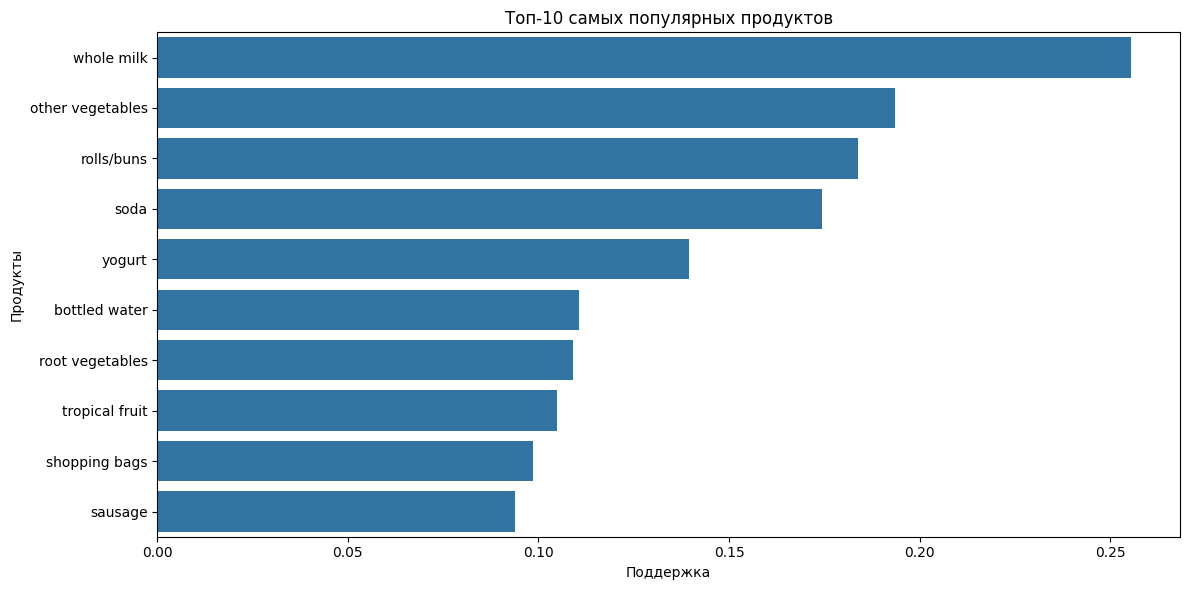

In [ ]:
#Поддержка
df1['itemsets'] = df1['itemsets'].apply(lambda x: ', '.join(list(x)))
top_products = df1.sort_values(by='support', ascending=False).head(10)
print(top_products)
plt.figure(figsize=(12, 6))
sns.barplot(x='support', y='itemsets', data=top_products)
plt.title('Топ-10 самых популярных продуктов')
plt.xlabel('Поддержка')
plt.ylabel('Продукты')
plt.tight_layout()
plt.show()


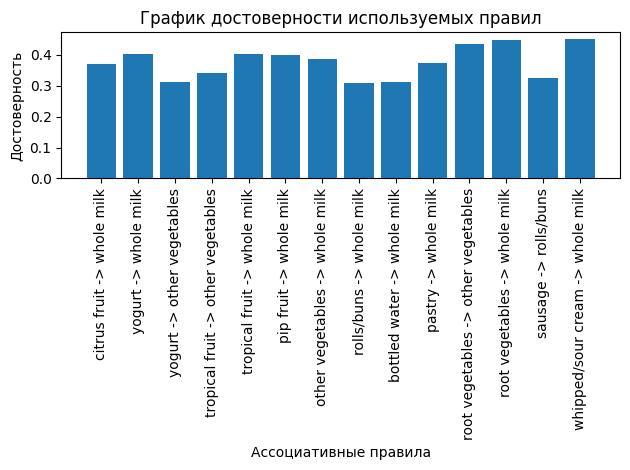

In [73]:
rules['antecedents'] = rules['antecedents'].apply(lambda x: ', '.join(list(x)))
rules['consequents'] = rules['consequents'].apply(lambda x: ', '.join(list(x)))

#График достоверности используемых правил
products_1 = rules["antecedents"].tolist()
products_2 = rules["consequents"].tolist()
confidence = rules["confidence"].tolist()
rules_labels = [f"{product1} -> {product2}" for product1, product2 in zip(products_1, products_2)]
plt.bar(rules_labels, confidence)
plt.xlabel("Ассоциативные правила")
plt.ylabel("Достоверность")
plt.title("График достоверности используемых правил")
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()

<Figure size 1200x800 with 0 Axes>

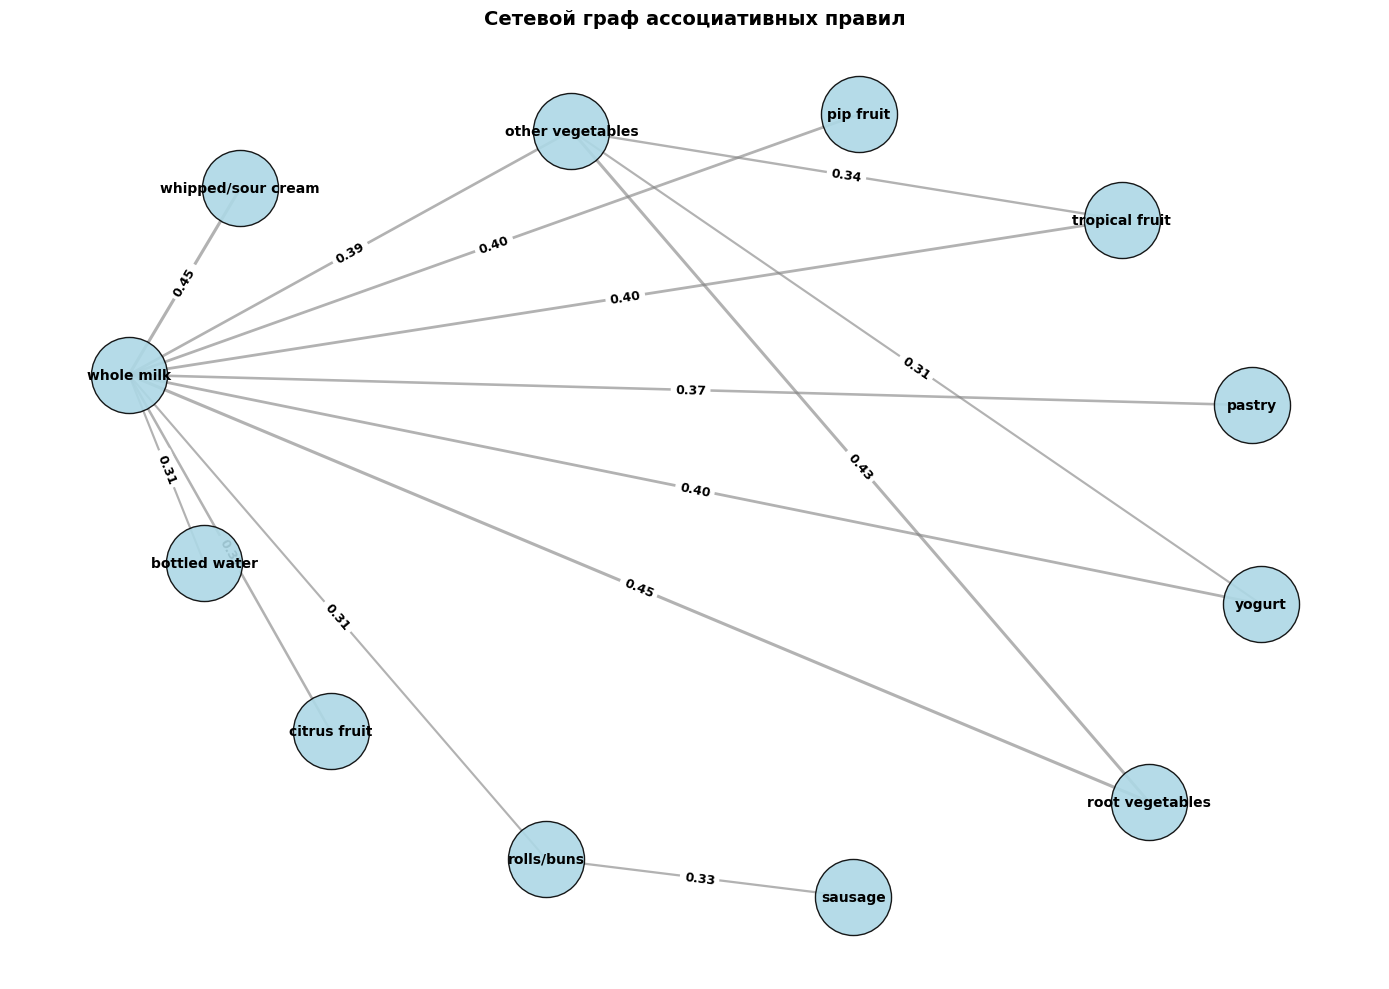

In [74]:
# Визуализация ассоциативных правил в виде графа
plt.figure(figsize=(12, 8))

G = nx.Graph()

for index, row in rules.iterrows():
    G.add_edge(row['antecedents'], row['consequents'], weight=row['confidence'])


pos = nx.spring_layout(G, k=3, iterations=50)

plt.figure(figsize=(14, 10))
nx.draw_networkx_nodes(G, pos, 
                      node_size=3000, 
                      node_color='lightblue',
                      alpha=0.9,
                      edgecolors='black')

edge_widths = [d['weight'] * 5 for (u, v, d) in G.edges(data=True)]
nx.draw_networkx_edges(G, pos, 
                      width=edge_widths, 
                      alpha=0.6, 
                      edge_color='gray')


nx.draw_networkx_labels(G, pos, 
                       font_size=10, 
                       font_weight='bold',
                       font_family='sans-serif')


edge_labels = {(u, v): f"{d['weight']:.2f}" for u, v, d in G.edges(data=True)}
nx.draw_networkx_edge_labels(G, pos, 
                            edge_labels=edge_labels,
                            font_size=9,
                            font_weight='bold')

plt.title('Сетевой граф ассоциативных правил', fontsize=14, fontweight='bold')
plt.axis('off')
plt.tight_layout()
plt.show()